<center>Universidade Federal de Viçosa</center>
<center>Coordenadoria de Educação Aberta e a Distância</center>
<center>Inteligência Artificial e Computacional</center>
<center>ELT578 - Análise de Imagens e Visão Computacional</center>

**<center>Desafio 2: Equalização em imagens RGB</center>**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

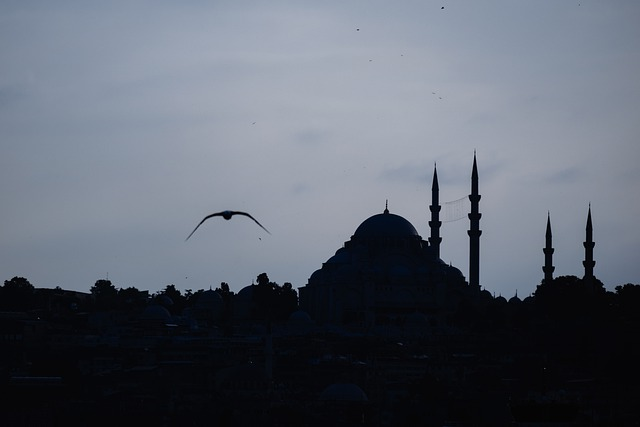

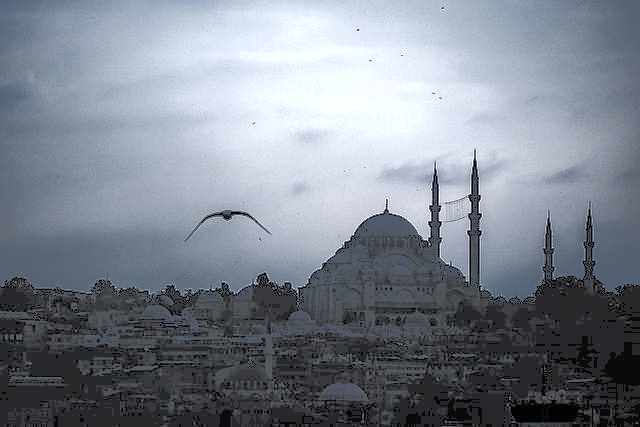

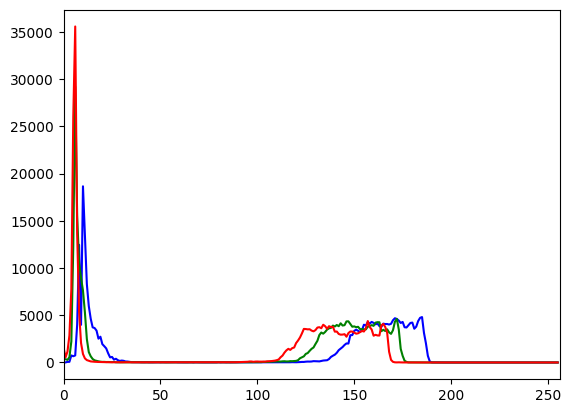

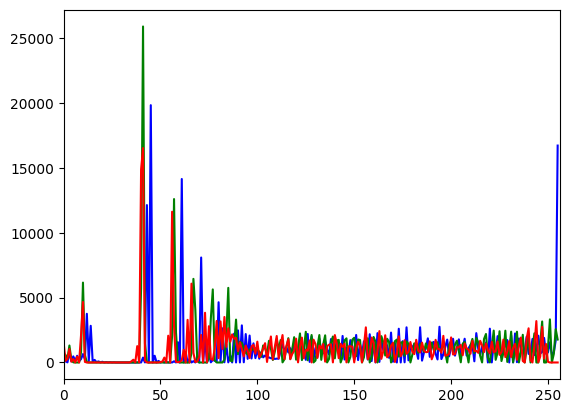

In [4]:
#EQUALIZAÇÃO - Processamento RGB

#Explicação
#OpenCV carrega imagens coloridas no espaço de cores BGR. Com este espaço de cores, não é possível equalizar o histograma sem afetar as informações de cores porque
#todos os 3 canais contêm informações de cores. Portanto, você deve converter a imagem BGR em um espaço de cores como YCrCb. No espaço de cores YCrCb, o canal Y da imagem contém apenas
#informações de intensidade, enquanto os canais Cr e Cb contêm todas as informações de cores da imagem. Portanto, apenas o canal Y deve ser processado para obter uma imagem equalizada do histograma
#sem alterar nenhuma informação de cor. Após o processamento, a imagem YCrCb deve ser convertida para o espaço de cores BGR antes de chamar a função imshow ().

from matplotlib import pyplot as plt

img = cv2.imread('/content/drive/MyDrive/ELT578/SEMANA_2/istanbul.jpg',1)
img_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV) #YUV

# equalize the histogram of the Y channel
img_yuv[:,:,0] = cv2.equalizeHist(img_yuv[:,:,0])

# convert the YUV image back to RGB format
img_output = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

cv2_imshow(img)
cv2_imshow(img_output)
cv2.imwrite('/content/drive/MyDrive/ELT578/SEMANA_2/Equalizacao_RBG.jpg', img_output, [int(cv2.IMWRITE_JPEG_QUALITY), 100])

color = ('b','g','r')

for i,col in enumerate(color):
    histr1 = cv2.calcHist([img],[i],None,[256],[0,256])
    plt.plot(histr1,color = col)
    plt.xlim([0,256])
plt.show()


for i,col in enumerate(color):
    histr2 = cv2.calcHist([img_output],[i],None,[256],[0,256])
    plt.plot(histr2,color = col)
    plt.xlim([0,256])
plt.show()